In [10]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib .pyplot as plt
plt.rcParams['figure.figsize']=(20.0,10.0)
#readind data 
df=pd.read_csv('Coffe_sales.csv')
print(df.shape)
df.head()

(3547, 11)


,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,10:15:50.520000
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:19:22.539000
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:20:18.089000
3,13,card,28.9,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,13:46:33.006000
4,13,card,38.7,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,13:48:14.626000


In [11]:
#calculating X and Y
X = df['hour_of_day'].values
Y = df['money'].values
#Mean of X and Y
mean_X=np.mean(X)
mean_Y=np.mean(Y)
# Total number of values
n=len(X)
# using the formula to calculate b1 and b0
numer = 0
denom = 0
for i in range(n):
    numer+=(X[i]-mean_X)*(Y[i]-mean_Y)
    denom+=(X[i]-mean_X)**2
b1 = numer/denom
b0 = mean_Y-(b1*mean_X)
#print coefficient
print(b1,b0)

0.23357398640440089 28.331783965630038


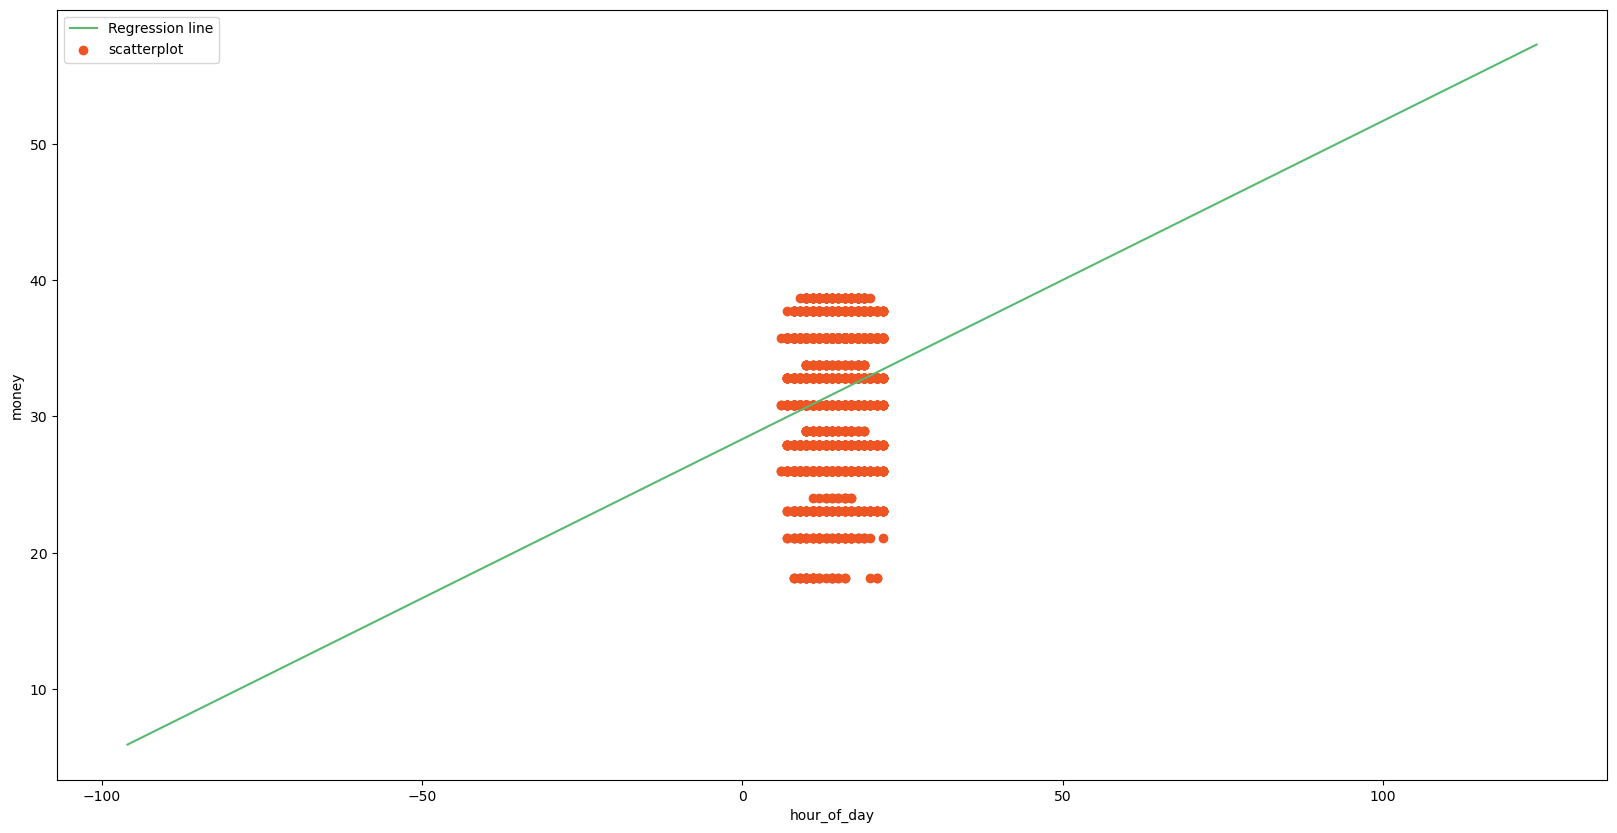

In [17]:
#ploting values and regression line
max_X = np.max(X)+100
min_X = np.min(X)-100
# calculating line value x and y
X = np.linspace(min_X,max_X,1000)
Y = b0+b1*X
#ploting line
plt.plot(X,Y,color='#58b970',label='Regression line')
#ploting scatter points
plt.scatter( df['hour_of_day'],df['money'],color='#ef5423',label='scatterplot')
plt.xlabel('hour_of_day')
plt.ylabel('money')
plt.legend()
plt.show()

In [21]:
#R2
ss_t = 0
ss_r = 0
for i in range(len(X)): 
    Y_pred = b0 + b1 * X[i]
    ss_t += (Y[i] - mean_Y) ** 2
    ss_r += (Y[i] - Y_pred) ** 2

r2 = 1-(ss_r/ss_t)
print(r2)

1.0


In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
#cannot use rank1 matrix
X=X.reshape((len(X),1))
#creating model
reg = LinearRegression()
reg.fit(X,Y)
#filtering training data
Y_pred = reg.predict(X)
#calculating R2 score
r2_score = reg.score(X,Y)
print(r2_score)

1.0
